In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from skimage.morphology import skeletonize
from scipy.signal import convolve2d
import os
import json

In [3]:
# Función para cargar una imagen groundtruth
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    # Se asume que la imagen es binaria: 0 (fondo) y 255 (estructura arterial)
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    return img_bin

In [4]:
# Función para aplicar esqueletonización (en caso de ser necesario)
def get_skeleton(img_bin):
    # Normalizamos a [0,1] para la función de skeletonize
    img_norm = img_bin // 255
    skeleton = skeletonize(img_norm).astype(np.uint8)
    return skeleton * 255

In [5]:
# Función para clasificar píxeles en función de su vecindario
def classify_pixels(skel):
    # Definir una estructura 3x3 para contar vecinos
    kernel = np.array([[1,1,1],
                       [1,10,1],
                       [1,1,1]])
    
    # Aplicamos la convolución para obtener la suma de vecinos
    from scipy.signal import convolve2d
    conv = convolve2d(skel//255, kernel, mode='same', boundary='fill', fillvalue=0)
    
    # Diccionario para almacenar nodos: cada entrada tendrá {id, fila, columna, tipo}
    nodes = []
    # Usaremos también una imagen para marcar los nodos (para visualización)
    node_img = np.copy(skel)
    
    # Lista de aristas, las cuales se definirán posteriormente
    # Por ahora, solo se identifican los puntos clave
    node_id = 0
    for i in range(1, skel.shape[0]-1):
        for j in range(1, skel.shape[1]-1):
            if skel[i, j] > 0:  # Es parte del esqueleto
                # El valor en el centro se suma con el peso 10, por lo que se resta
                neighbor_count = int((conv[i,j] - 10))
                
                # Clasificación simple:
                if neighbor_count == 1:
                    tipo = "extremo"  # punto final
                elif neighbor_count > 2:
                    tipo = "bifurcacion"  # se considera punto de ramificación
                else:
                    tipo = "intermedio"
                
                nodes.append({'id': node_id, 'fila': i, 'columna': j, 'tipo': tipo})
                node_id += 1
                # Para visualización, podemos marcar los nodos con un valor distinto
                node_img[i, j] = 128
    return nodes, node_img

In [6]:
# Función para construir aristas: ejemplo de método (rastrear línea hasta el siguiente nodo)
def construct_edges(skel, nodes):
    # Convertir la lista de nodos en un diccionario para acceso rápido por coordenadas
    node_coords = {(n['fila'], n['columna']): n['id'] for n in nodes}
    
    # Se inicializa el grafo de networkx
    G = nx.Graph()
    for n in nodes:
        G.add_node(n['id'], fila=n['fila'], columna=n['columna'], tipo=n['tipo'])
    
    # Una estrategia es recorrer cada nodo y realizar un "búsqueda en profundidad" a lo largo del esqueleto
    # hasta encontrar otro nodo, registrando la conexión.
    # NOTA: Este es un ejemplo simplificado; en la práctica se deben evitar caminos redundantes y asegurar conectividad.
    
    # Definimos movimientos vecinos (8 direcciones)
    vecinos = [(-1,-1), (-1,0), (-1,1),
               (0,-1),          (0,1),
               (1,-1),  (1,0),  (1,1)]
    
    # Función para rastrear un camino a partir de un nodo dado
    def rastrear(i, j, visitados):
        camino = [(i,j)]
        while True:
            vecinos_validos = []
            for di, dj in vecinos:
                ni, nj = i+di, j+dj
                if 0 <= ni < skel.shape[0] and 0 <= nj < skel.shape[1]:
                    if skel[ni, nj] > 0 and (ni, nj) not in visitados:
                        vecinos_validos.append((ni, nj))
            if len(vecinos_validos) == 0:
                break
            # Tomamos el primer vecino disponible (podrías mejorar la estrategia)
            i, j = vecinos_validos[0]
            camino.append((i,j))
            visitados.add((i,j))
            # Si se encuentra un nodo (excepto el de inicio) se termina el camino
            if (i,j) in node_coords:
                return camino, node_coords[(i,j)]
        return camino, None

    # Conjunto para marcar caminos ya explorados
    visitados_global = set()
    for n in nodes:
        i, j = n['fila'], n['columna']
        for di, dj in vecinos:
            ni, nj = i+di, j+dj
            if 0 <= ni < skel.shape[0] and 0 <= nj < skel.shape[1]:
                if skel[ni, nj] > 0 and (ni, nj) not in visitados_global:
                    camino, nodo_final = rastrear(ni, nj, visitados_global)
                    if nodo_final is not None and nodo_final != n['id']:
                        # Añadir arista si no existe aún
                        if not G.has_edge(n['id'], nodo_final):
                            G.add_edge(n['id'], nodo_final, pixels=camino)
    return G

In [7]:

# Ruta a la carpeta de imágenes
ruta_imagenes = "datos/etiquetas/"

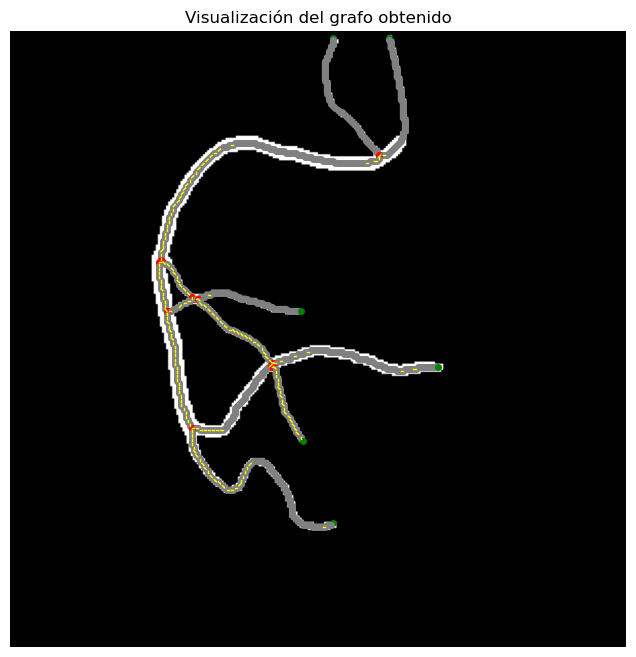

In [8]:
# Ejemplo para procesar una imagen
nombre_imagen = os.path.join(ruta_imagenes, "1.pgm")  # Cambia "ejemplo.pgm" por el nombre de tu imagen
img_bin = load_image(nombre_imagen)
# Si la imagen no es una línea única, podrías aplicar la esqueletonización:
skel = get_skeleton(img_bin)

# Clasificar píxeles y obtener nodos
nodos, img_nodos = classify_pixels(skel)

# Construir aristas y grafo
grafo = construct_edges(skel, nodos)

# Guardar la estructura del grafo en un archivo JSON
grafo_json = {
    "nodos": nodos,
    "aristas": [{"nodo1": u, "nodo2": v, "camino": grafo[u][v]['pixels']} for u, v in grafo.edges()]
}
with open("grafo_estructura.json", "w") as f:
    json.dump(grafo_json, f, indent=4)

# Visualización: superponer el grafo sobre la imagen original
plt.figure(figsize=(8, 8))
plt.imshow(img_bin, cmap='gray')
# Dibujar nodos con colores según su tipo
for n in nodos:
    if n['tipo'] == "extremo":
        color = "green"
    elif n['tipo'] == "bifurcacion":
        color = "red"
    else:
        color = "gray"
    plt.plot(n['columna'], n['fila'], 'o', color=color, markersize=4)

# Dibujar aristas
for u, v in grafo.edges():
    camino = np.array(grafo[u][v]['pixels'])
    plt.plot(camino[:,1], camino[:,0], color='yellow', linewidth=1)

plt.title("Visualización del grafo obtenido")
plt.axis("off")
plt.show()